- ### RBF

RBF (Radial Basis Function) kernel. It maps data to higher dimensions where it becomes separable. Think of it as folding the paper so points that weren't separable become separable.

- ### The C Parameter (Regularization)

C is the "trade-off" parameter:

Small C (0.1): Soft margin, allows misclassifications, simpler boundary

Large C (10): Hard margin, tries to classify EVERY point correctly, complex boundary

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Load the breast cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# IMPORTANT: SVM is sensitive to feature scaling
# Standardize features (mean=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Try different C values
C_values = [0.1, 1, 10]
accuracies = {}

for C in C_values:
    # Create SVM with RBF kernel
    svm = SVC(kernel='rbf', C=C, random_state=42)
    
    # Train the model
    svm.fit(X_train, y_train)
    
    # Predict on test set
    y_pred = svm.predict(X_test)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    accuracies[C] = accuracy
    
    print(f"C = {C:4.1f} | Accuracy: {accuracy:.4f}")

print("\nAccuracies:", accuracies)

C =  0.1 | Accuracy: 0.9474
C =  1.0 | Accuracy: 0.9737
C = 10.0 | Accuracy: 0.9737

Accuracies: {0.1: 0.9473684210526315, 1: 0.9736842105263158, 10: 0.9736842105263158}


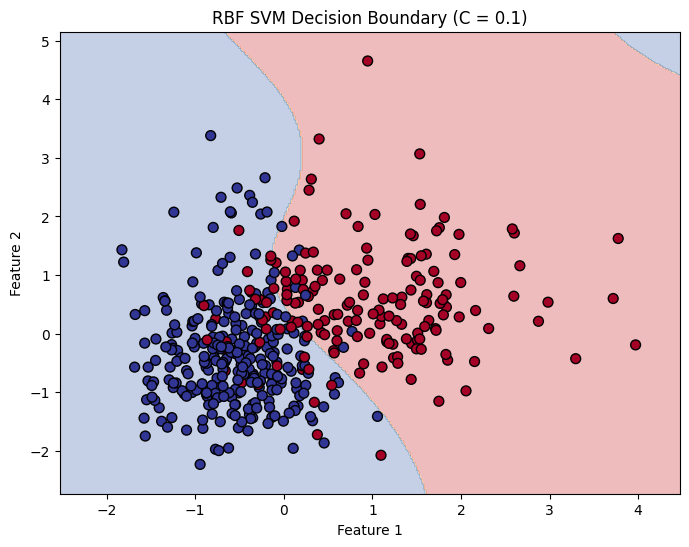

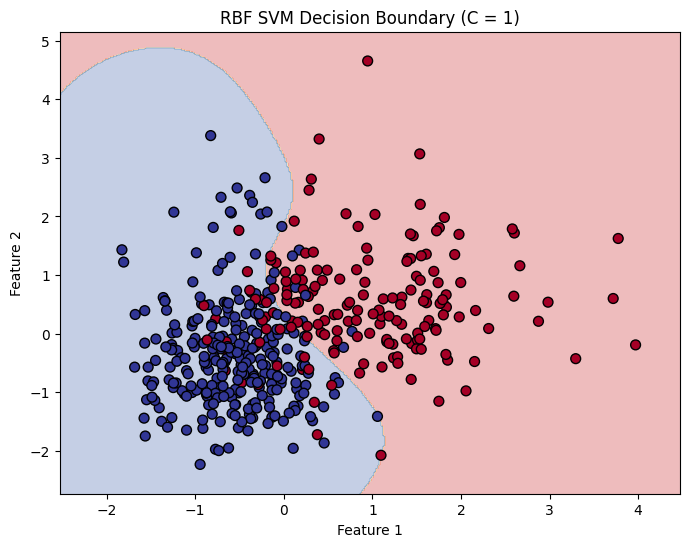

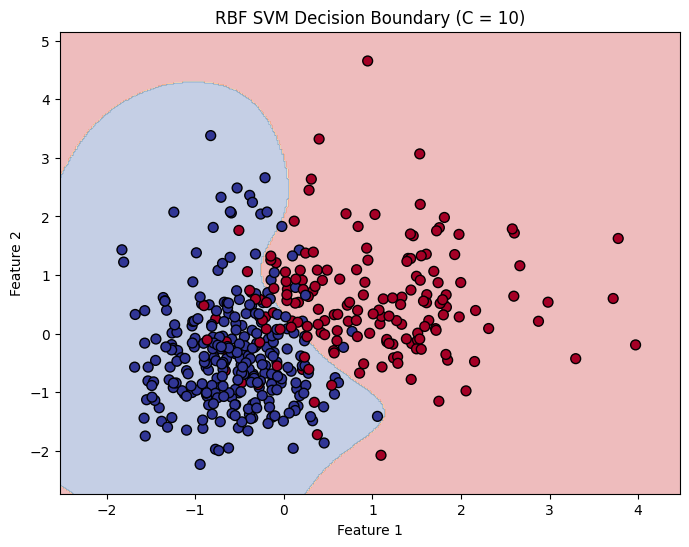

In [13]:
# Take only 2 features for visualization
X_2d = X_scaled[:, :2]  # First two features
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y, test_size=0.2, random_state=42
)

# Create a mesh to plot decision boundaries
def plot_decision_boundary(C_value):
    svm = SVC(kernel='rbf', C=C_value, random_state=42)
    svm.fit(X_train_2d, y_train_2d)
    
    # Create grid
    x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
    y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    # Predict on grid
    Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], 
                c=y_train_2d, cmap=plt.cm.RdYlBu, 
                edgecolors='black', s=50)
    plt.title(f'RBF SVM Decision Boundary (C = {C_value})')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

# Plot for each C value
for C in [0.1, 1, 10]:
    plot_decision_boundary(C)

| Feature | Small C (0.1) | Large C (10) |
|---------|---------------|--------------|
| **Boundary** | Simple, smooth | Complex, wiggly |
| **Bias-Variance** | High bias | High variance |
| **Risk** | Underfitting risk | Overfitting risk |
| **Generalization** | Better generalization | May memorize training data |
| **Margin** | Wider margin | Narrower margin |
| **Training Accuracy** | More misclassifications | Fewer misclassifications |


- C=0.1: Might have slightly lower accuracy but more stable
- C=1: Good balance (often the default for a reason)
- C=10: Similar or slightly better accuracy, but risk of overfitting

### Tips for Your Learning Journey

- Always scale your data before SVM (we used StandardScaler)
- C is like a knob - tune it to find the sweet spot
- If accuracy doesn't change much, the dataset might be well-separated already
- Check training vs test accuracy to spot overfitting:

In [11]:
# lets check if it's overfitting
train_acc = svm.score(X_train, y_train)
test_acc = svm.score(X_test, y_test)
print(f"Train: {train_acc:.4f}, Test: {test_acc:.4f}")
# If train >> test, you're overfitting (use smaller C)

Train: 0.9934, Test: 0.9737


In [14]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Load and scale data
data = load_breast_cancer()
X, y = data.data, data.target
X_scaled = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Test different C values with BOTH train and test accuracy
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

print("C     | Train Acc | Test Acc  | Overfit?")
print("------|-----------|-----------|---------")
for C in C_values:
    svm = SVC(kernel='rbf', C=C, random_state=42)
    svm.fit(X_train, y_train)
    
    train_acc = svm.score(X_train, y_train)
    test_acc = svm.score(X_test, y_test)
    
    overfit = "YES ⚠️" if (train_acc - test_acc) > 0.05 else "No ✓"
    print(f"{C:6.3f} | {train_acc:.4f}   | {test_acc:.4f}   | {overfit}")

C     | Train Acc | Test Acc  | Overfit?
------|-----------|-----------|---------
 0.001 | 0.6286   | 0.6228   | No ✓
 0.010 | 0.6286   | 0.6228   | No ✓
 0.100 | 0.9560   | 0.9474   | No ✓
 1.000 | 0.9868   | 0.9737   | No ✓
10.000 | 0.9934   | 0.9737   | No ✓
100.000 | 1.0000   | 0.9386   | YES ⚠️
1000.000 | 1.0000   | 0.9386   | YES ⚠️


In [16]:
from sklearn.model_selection import GridSearchCV
import pandas as pd

# Define parameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1, 10]  # RBF kernel parameter
}

# Grid search with cross-validation
svm = SVC(kernel='rbf', random_state=42)
grid_search = GridSearchCV(
    svm, 
    param_grid, 
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',
    verbose=1,
    n_jobs=-1  # Use all CPU cores
)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")
print(f"Test accuracy: {grid_search.score(X_test, y_test):.4f}")

# See all results
results = pd.DataFrame(grid_search.cv_results_)
print("\nTop 5 parameter combinations:")
print(results[['param_C', 'param_gamma', 'mean_test_score']].head())

Fitting 5 folds for each of 25 candidates, totalling 125 fits


Best parameters: {'C': 10, 'gamma': 0.01}
Best cross-validation score: 0.9736
Test accuracy: 0.9825

Top 5 parameter combinations:
   param_C  param_gamma  mean_test_score
0     0.01        0.001         0.628571
1     0.01        0.010         0.628571
2     0.01        0.100         0.628571
3     0.01        1.000         0.628571
4     0.01       10.000         0.628571


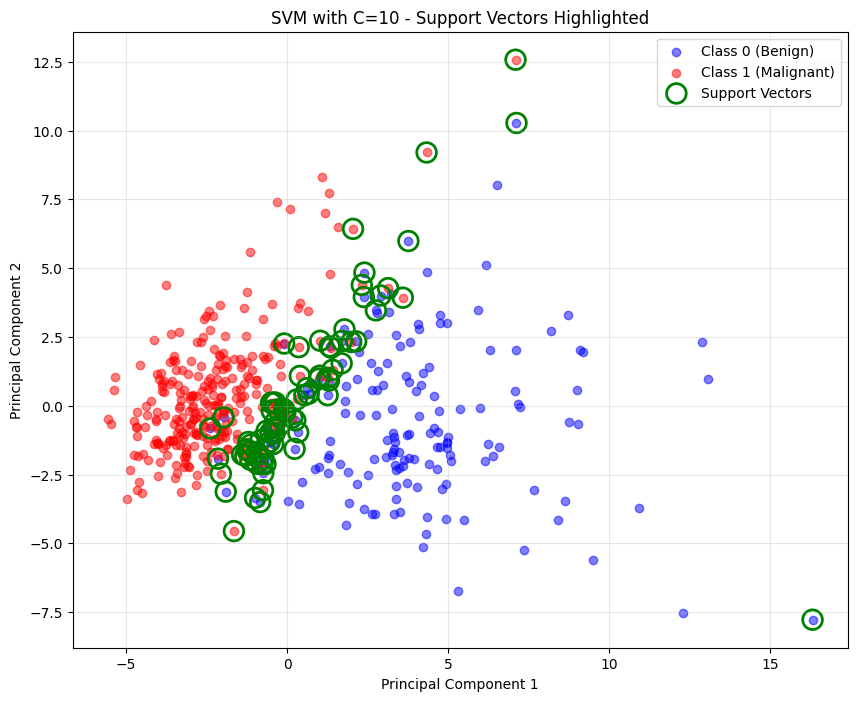

Number of support vectors: 78
Support vector ratio: 17.14%


In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA   #Principle Component Analysis

# Reduce to 2D for visualization using PCA
pca = PCA(n_components=2)
#PCA(n_components=2) — Configures PCA to reduce data to 2 dimensions (for 2D visualization)
X_pca = pca.fit_transform(X_scaled)

# Split PCA data
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

# Train with best C
best_C = 10
svm = SVC(kernel='rbf', C=best_C, gamma=0.01, random_state=42)
# gamma=0.01 — Kernel coefficient (controls influence of single training point)
svm.fit(X_train_pca, y_train_pca)

# Get support vectors
# svm.support_vectors_ — Attribute storing the actual data points that are support vectors
# support_vectors — A 2D array of the support vector coordinates
support_vectors = svm.support_vectors_
support_indices = svm.support_

# Plot
plt.figure(figsize=(10, 8))

# Plot all training points
plt.scatter(X_train_pca[y_train_pca==0, 0], X_train_pca[y_train_pca==0, 1], 
            c='blue', label='Class 0 (Benign)', alpha=0.5)
plt.scatter(X_train_pca[y_train_pca==1, 0], X_train_pca[y_train_pca==1, 1], 
            c='red', label='Class 1 (Malignant)', alpha=0.5)

# Highlight support vectors
plt.scatter(support_vectors[:, 0], support_vectors[:, 1], 
            s=200, facecolors='none', edgecolors='green', 
            linewidths=2, label='Support Vectors')

plt.title(f'SVM with C={best_C} - Support Vectors Highlighted')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Number of support vectors: {len(support_vectors)}")
print(f"Support vector ratio: {len(support_vectors)/len(X_train_pca):.2%}")

In [24]:
# Compare Different Kernels

kernels = ['linear','poly','rbf','sigmoid']
results = {}

for kernel in kernels:
    # Different parameters for different kernels
    if kernel == 'poly':
        svm = SVC(kernel=kernel, C=10,degree=3,random_state=42)
    else:
        svm = SVC(kernel=kernel, C=10,random_state=42)

    svm.fit(X_train,y_train)
    train_acc = svm.score(X_train, y_train)
    test_acc = svm.score(X_test, y_test)
    results[kernel] = {'train': train_acc, 'test': test_acc}
    
    print(f"{kernel:8} | Train: {train_acc:.4f} | Test: {test_acc:.4f}")

# Find best
best_kernel = max(results, key=lambda x: results[x]['test'])
print(f"\n🏆 Best kernel: {best_kernel} with test accuracy {results[best_kernel]['test']:.4f}")

"""
Degree 1 (Linear):   ____/‾‾‾‾\____    (too simple)
Degree 2 (Quadratic):  ~‾‾‾‾~        (simple curve)
Degree 3 (Cubic):     ~~‾‾‾‾~~       (good flexibility) ← ✅ SWEET SPOT
Degree 5+:            ~~~~~~~~~~      (too wiggly, overfits)
"""

linear   | Train: 0.9912 | Test: 0.9649
poly     | Train: 0.9692 | Test: 0.9561
rbf      | Train: 0.9934 | Test: 0.9737
sigmoid  | Train: 0.9297 | Test: 0.9561

🏆 Best kernel: rbf with test accuracy 0.9737


'\nDegree 1 (Linear):   ____/‾‾‾‾\\____    (too simple)\nDegree 2 (Quadratic):  ~‾‾‾‾~        (simple curve)\nDegree 3 (Cubic):     ~~‾‾‾‾~~       (good flexibility) ← ✅ SWEET SPOT\nDegree 5+:            ~~~~~~~~~~      (too wiggly, overfits)\n'

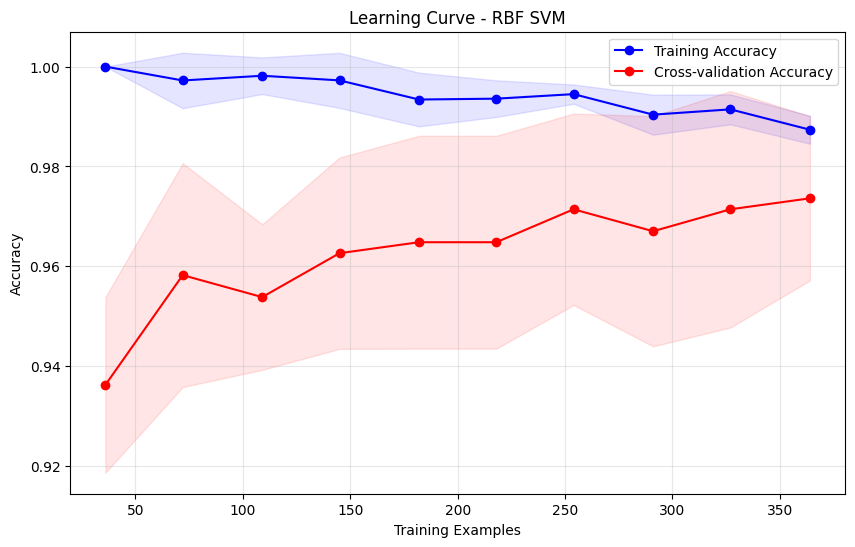

In [25]:
from sklearn.model_selection import learning_curve

# Generate learning curve
train_sizes, train_scores, test_scores = learning_curve(
    SVC(kernel='rbf', C=10, gamma=0.01, random_state=42),
    X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Calculate means and stds
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Accuracy')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'o-', color='red', label='Cross-validation Accuracy')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='red')

plt.xlabel('Training Examples')
plt.ylabel('Accuracy')
plt.title('Learning Curve - RBF SVM')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

In [26]:
from sklearn.inspection import permutation_importance

# Train final model
svm_final = SVC(kernel='rbf', C=10, gamma=0.01, random_state=42)
svm_final.fit(X_train, y_train)

# Permutation importance
result = permutation_importance(
    svm_final, X_test, y_test, 
    n_repeats=10, 
    random_state=42,
    n_jobs=-1
)

# Get top 10 most important features
feature_names = data.feature_names
importance_scores = result.importances_mean
top_indices = np.argsort(importance_scores)[-10:][::-1]

print("Top 10 Most Important Features:")
print("-" * 40)
for idx in top_indices:
    print(f"{feature_names[idx]:25} | {importance_scores[idx]:.4f}")

Top 10 Most Important Features:
----------------------------------------
mean concave points       | 0.0193
worst texture             | 0.0132
worst radius              | 0.0114
worst smoothness          | 0.0105
mean concavity            | 0.0079
radius error              | 0.0061
worst area                | 0.0061
compactness error         | 0.0061
worst compactness         | 0.0053
mean compactness          | 0.0053
